In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_recall_fscore_support,
    f1_score,
)
from sklearn.linear_model import LogisticRegression

import xgboost as xgb

from pathlib import Path
import joblib

artifacts_dir = Path("artifacts")
pre = joblib.load(artifacts_dir / "preprocessing_artifacts.joblib")
train = joblib.load(artifacts_dir / "training_artifacts.joblib")

globals().update(pre)
globals().update(train)

print("Loaded artifacts from", artifacts_dir)


Loaded artifacts from artifacts


## 6. Model Evaluation and Comparison

In [2]:
# Summary table (all models)
comparison = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Random Forest", "XGBoost", "DNN", "Stacking (LR+RF+XGB+DNN)"],
    "Accuracy": [results_lr_simple["accuracy"], results_rf["accuracy"], results_xgb["accuracy"], results_dnn["accuracy"], results_stack["accuracy"]],
    "ROC-AUC": [
        results_lr_simple.get("roc_auc") or (roc_auc_score(y_test, results_lr_simple["probabilities"]) if results_lr_simple.get("probabilities") is not None else 0.5),
        results_rf.get("roc_auc") or roc_auc_score(y_test, results_rf["probabilities"]),
        results_xgb.get("roc_auc") or roc_auc_score(y_test, results_xgb["probabilities"]),
        results_dnn.get("roc_auc") or roc_auc_score(y_test, results_dnn["probabilities"]),
        results_stack.get("roc_auc") or roc_auc_score(y_test, results_stack["probabilities"])
    ],
    "Precision (Low)": [results_lr_simple.get("precision_low", 0), results_rf.get("precision_low", 0), results_xgb.get("precision_low", 0), results_dnn.get("precision_low", 0), results_stack.get("precision_low", 0)],
    "Recall (Low)": [results_lr_simple.get("recall_low", 0), results_rf.get("recall_low", 0), results_xgb.get("recall_low", 0), results_dnn.get("recall_low", 0), results_stack.get("recall_low", 0)],
    "F1 (Low)": [results_lr_simple.get("f1_low", 0), results_rf.get("f1_low", 0), results_xgb.get("f1_low", 0), results_dnn.get("f1_low", 0), results_stack.get("f1_low", 0)],
    "Precision (High)": [results_lr_simple.get("precision_high", 0), results_rf.get("precision_high", 0), results_xgb.get("precision_high", 0), results_dnn.get("precision_high", 0), results_stack.get("precision_high", 0)],
    "Recall (High)": [results_lr_simple.get("recall_high", 0), results_rf.get("recall_high", 0), results_xgb.get("recall_high", 0), results_dnn.get("recall_high", 0), results_stack.get("recall_high", 0)],
    "F1 (High)": [results_lr_simple.get("f1_high", 0), results_rf.get("f1_high", 0), results_xgb.get("f1_high", 0), results_dnn.get("f1_high", 0), results_stack.get("f1_high", 0)]
})
print(comparison.to_string(index=False))

                         Model  Accuracy  ROC-AUC  Precision (Low)  Recall (Low)  F1 (Low)  Precision (High)  Recall (High)  F1 (High)
Logistic Regression (baseline)  0.674033 0.724261         0.892791      0.676111  0.769488          0.332736       0.665472   0.443648
                 Random Forest  0.759300 0.809227         0.910799      0.776977  0.838583          0.427599       0.686465   0.526957
                       XGBoost  0.751900 0.822218         0.922264      0.755354  0.830506          0.422566       0.737669   0.537328
                           DNN  0.675933 0.756578         0.906055      0.666377  0.767949          0.342262       0.715310   0.462992
      Stacking (LR+RF+XGB+DNN)  0.739067 0.822316         0.927198      0.733317  0.818939          0.409737       0.762758   0.533103


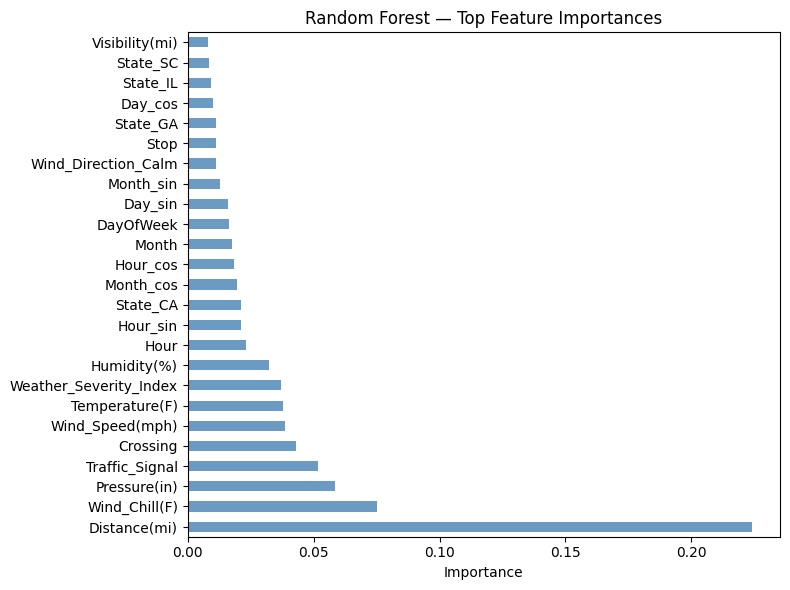

In [3]:
# Feature importance (Random Forest)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_n = min(25, len(imp))
imp.head(top_n).plot(kind="barh", figsize=(8, 6), color="steelblue", alpha=0.8)
plt.title("Random Forest — Top Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation
- **Models:** Logistic Regression (baseline) is compared with RF, XGBoost, DNN, and Stacking; tree-based and stacked models often improve on ROC-AUC and F1 (High).
- **Imbalance:** The data is ~80% Low, ~20% High. Models tuned for F1 (High) predict more Highs to catch high-severity cases. For identifying high-severity accidents, **F1 (High)** and **ROC-AUC** are the main metrics.
- **LR vs RF/XGBoost:** Random Forest and XGBoost often outperform the Logistic Regression (baseline) (especially on ROC-AUC). The gains are modest because the problem is inherently difficult and we use limited tuning.
- **Why performance is modest:** Severity is influenced by many unmeasured factors; we use a subset of features and limited tuning. This is normal for a first pass.
- **Conclusion:** The pipeline works: ensemble and tree-based models can improve on the Logistic Regression (baseline) for ROC-AUC and F1 (High). To improve further, add more tuning, features, or resampling.

## 7 Model Improvement Experiments

In [4]:
# Threshold tuning: find threshold that maximizes F1 for High Severity (positive class)
from sklearn.metrics import precision_recall_curve

y_proba_xgb = results_xgb["probabilities"]
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb, pos_label=1)
f1_scores = 2 * precision * recall / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores[:-1])  # last entry is undefined
best_threshold = thresholds[best_idx]
print(f"Best F1 (High) at threshold = {best_threshold:.4f}")

y_pred_tuned = (y_proba_xgb >= best_threshold).astype(int)
f1_high_tuned = f1_score(y_test, y_pred_tuned, pos_label=1, zero_division=0)
print(f"F1 (High) with default 0.5: {results_xgb.get('f1_high', 0):.4f}")
print(f"F1 (High) with tuned threshold: {f1_high_tuned:.4f}")

Best F1 (High) at threshold = 0.5787
F1 (High) with default 0.5: 0.5373
F1 (High) with tuned threshold: 0.5459


In [5]:
# SMOTE on training set, then retrain one model (e.g. Logistic Regression (baseline))

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
lr_smote = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_smote.fit(X_train_resampled, y_train_resampled)
y_pred_smote = lr_smote.predict(X_test_scaled)
f1_high_smote = f1_score(y_test, y_pred_smote, pos_label=1, zero_division=0)
print(f"LR with SMOTE — F1 (High): {f1_high_smote:.4f}")


LR with SMOTE — F1 (High): 0.4412


In [6]:
# Stronger class weight: retrain XGBoost with 2x scale_pos_weight to predict more High severity
# (Increases recall for High; F1 may go up or down depending on precision trade-off.)
scale_pos_strong = 2.0 * (y_train == 0).sum() / max((y_train == 1).sum(), 1)
params = xgb_search.best_params_
xgb_strong = xgb.XGBClassifier(**params, random_state=42, scale_pos_weight=scale_pos_strong)
xgb_strong.fit(X_train_scaled, y_train)
y_pred_strong = xgb_strong.predict(X_test_scaled)
y_proba_strong = xgb_strong.predict_proba(X_test_scaled)[:, 1]
f1_high_strong = f1_score(y_test, y_pred_strong, pos_label=1, zero_division=0)
p_high, r_high, _, _ = precision_recall_fscore_support(y_test, y_pred_strong, average="binary", pos_label=1)
print("XGBoost with 2x scale_pos_weight:")
print(f"  F1 (High): {f1_high_strong:.4f}  Precision (High): {p_high:.4f}  Recall (High): {r_high:.4f}")
print(f"  Original XGBoost F1 (High): {results_xgb.get('f1_high', 0):.4f}")

XGBoost with 2x scale_pos_weight:
  F1 (High): 0.5022  Precision (High): 0.3580  Recall (High): 0.8408
  Original XGBoost F1 (High): 0.5373


## 8. Conclusions

- **Task:** We predicted binary **High_Severity** (Severity 3 or 4) using weather, time, infrastructure, and location (state) features from the US Accidents cleaned dataset.
- **Models:** Logistic Regression (baseline), Random Forest, XGBoost, DNN (MLP), and Stacking (LR+RF+XGB+DNN) were trained with class weighting to handle imbalance.
- **Evaluation:** Accuracy and ROC-AUC were used; the comparison table and confusion matrices show trade-offs between precision and recall for the minority (high-severity) class.
- **Leakage safety:** For deployment-style prediction, we exclude post-incident/future-only fields (e.g., `Description`, end time, and duration-derived features).
- **Next steps:** Trying new models, additional features (e.g. geographic clustering), or using the raw US_Accidents dataset with a larger sample for more robust estimates.